# Collisions of room-temperature helium with ultracold lithium

Reproduction of Makrides et al. Figures 1, 3, and 5 Lithium on Helium cross sections.

In [1]:
import sys

sys.path.append('../src/')
sys.path.append('../src/AtomicTrit')

from AtomicTrit import constants
from AtomicTrit import elastic
from AtomicTrit import potentials
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

In [2]:
# Here are the potentials and masses we will need

potential_names = list(potentials.LiHePotentials)
scattering_names = [n for n in potential_names if n not in ('CSD','KTTY')]
colors = {'CC-TZ':'#16b7b3', 'CC-QZ':'#2878bd', 'CC-5Z':'#d33b36', 'CC-Infinity':'black', 'CSD':'#8b4513', 'KTTY':'#e67e22'}
styles = {'CC-TZ':(0,(7,2,1,2)), 'CC-QZ':'-.', 'CC-5Z':'--', 'CC-Infinity':'-', 'CSD':'-', 'KTTY':'-'}
labels = {'CC-TZ':r'$V^{TZ}$', 'CC-QZ':r'$V^{QZ}$', 'CC-5Z':r'$V^{5Z}$', 'CC-Infinity':r'$V^{\infty Z}$', 'CSD':'CSD', 'KTTY':'KTTY'}
def paper_axes(ax):
    ax.tick_params(direction='in', top=True, right=True)
HeMasses = {3:3.0160293, 4:4.00260325413}
LiMasses = {6:6.0151228874, 7:7.0160034366}
def reduced_mass(he=4, li=7):
    return (HeMasses[he] * LiMasses[li]
            / (HeMasses[he] + LiMasses[li])
            * constants.DaltonInEV)
mu = reduced_mass()
rhos = np.linspace(3., 150., 1200)*constants.BohrInEV

## Figure 1 — HeLi potentials

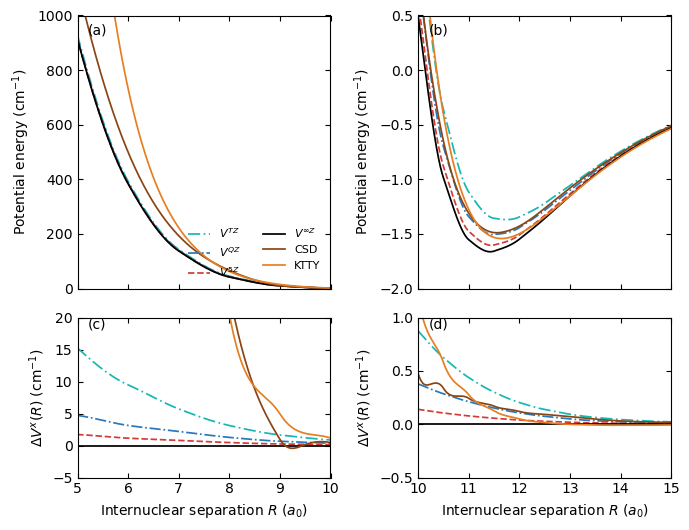

In [3]:
R = np.linspace(3.,20.,1400); rho = R*constants.BohrInEV
V = {n:np.asarray(f(rho))/constants.cmm1_in_eV for n,f in potentials.LiHePotentials.items()}
dV = {n:V[n]-V['CC-Infinity'] for n in V}
fig, ax = plt.subplots(2,2,figsize=(7,5.4),sharex='col',gridspec_kw={'height_ratios':[1.45,.85]})
panels = [(ax[0,0],V,(5,10),(0,1000)),(ax[0,1],V,(10,15),(-2,.5)),(ax[1,0],dV,(5,10),(-5,20)),(ax[1,1],dV,(10,15),(-.5,1))]
for i,(a,values,xlim,ylim) in enumerate(panels):
    for n,y in values.items():
        a.plot(R,y,color=colors[n],linestyle=styles[n],linewidth=1.25,label=labels[n])
    paper_axes(a); a.set_xlim(*xlim); a.set_ylim(*ylim); a.text(.04,.93,f'({chr(97+i)})',transform=a.transAxes)
    a.set_ylabel('Potential energy (cm$^{-1}$)' if i < 2 else r'$\Delta V^x(R)$ (cm$^{-1}$)')
ax[1,0].set_xlabel(r'Internuclear separation $R$ ($a_0$)'); ax[1,1].set_xlabel(r'Internuclear separation $R$ ($a_0$)')
ax[0,0].legend(frameon=False,fontsize=8,ncol=2,loc='lower right')
fig.tight_layout(); plt.show()

## Figure 3 — total elastic cross sections

In [4]:
EnergyOverKB = np.linspace(1., 3000., 250)
CrossSections = {}

def partial_waves(E):
    p = np.sqrt(2 * mu * E * constants.K2eV)
    lmax = min(200, int(p * 20. * constants.BohrInEV) + 10)
    return np.arange(0, lmax + 1)

# Ran into issues using Radau switched to DOP853 but the tolerances needed to be tighter for accurate phase shifts.
_solve_ivp = elastic.scipy.integrate.solve_ivp
def solve_ivp_tight(*args, **kwargs):
    kwargs.setdefault('rtol', 1e-7)
    kwargs.setdefault('atol', 1e-9)
    return _solve_ivp(*args, **kwargs)
elastic.scipy.integrate.solve_ivp = solve_ivp_tight
for name in scattering_names:
    CrossSections[name] = np.array([
        sum(
            elastic.GetCrossSection(
                rhos,
                np.sqrt(2 * mu * E * constants.K2eV),
                l,
                mu,
                potentials.LiHePotentials[name],
                'DOP853',
            ) / 2
            for l in partial_waves(E)
        )
        for E in EnergyOverKB
    ]) / constants.BohrInEV**2
print('Cross sections computed; plotting is in the next cell.')

Cross sections computed; plotting is in the next cell.


### Plot Figure 3 from the computed arrays

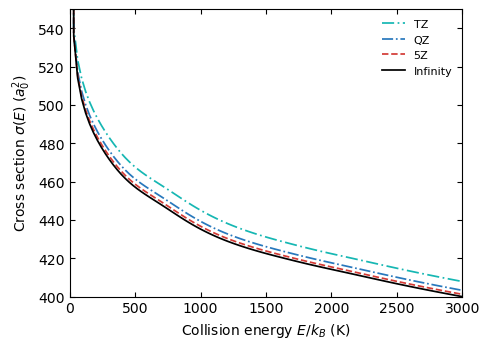

In [5]:
# I didnt plot KTTY or CSD for computation time purposes, but the architecture is here
fig, ax = plt.subplots(figsize=(5,3.6))
for n,y in CrossSections.items():
    marker = 's' if n == 'CSD' else ('o' if n == 'KTTY' else None)
    ax.plot(EnergyOverKB,y,color=colors[n],linestyle=styles[n],linewidth=1.25 if marker is None else 0,marker=marker,markevery=7,markersize=3,label=n.replace('CC-',''))
paper_axes(ax); ax.set_xlim(0,3000); ax.set_ylim(400,550)
ax.set_xlabel(r'Collision energy $E/k_B$ (K)'); ax.set_ylabel(r'Cross section $\sigma(E)$ ($a_0^2$)'); ax.legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()

## Figure 5 — thermalized rate coefficients

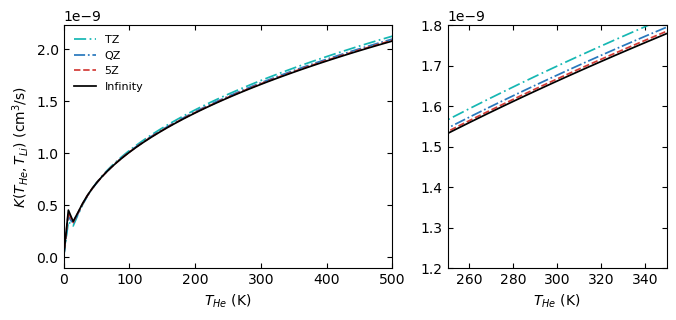

np.float64(1.6549770844659345e-09)

In [6]:
kB_SI=constants.kb; u_SI=1.66053906660e-27; a0_SI=5.29177210903e-11
def T_eff(TLi,THe): return (HeMasses[4]*TLi+LiMasses[7]*THe)/(HeMasses[4]+LiMasses[7])
mu_kg = reduced_mass()*u_SI/constants.DaltonInEV
def thermalization_rate(E_over_kB,sigma_a0sq,TLi,THe):
    te=T_eff(TLi,THe); z=np.asarray(E_over_kB)/te
    integral=trapezoid(z*np.exp(-z)*np.asarray(sigma_a0sq)*a0_SI**2,z)
    # Corrected normalization from the 2022 erratum: 2/sqrt(pi).
    return (2/np.sqrt(np.pi))*np.sqrt(2*kB_SI*te/mu_kg)*integral*1e6
THe_values=np.linspace(.1,500.,70); TLi=1e-6
Rates={n:np.array([thermalization_rate(EnergyOverKB,CrossSections[n],TLi,t) for t in THe_values]) for n in scattering_names}
fig,(ax,inset)=plt.subplots(1,2,figsize=(7,3.3),gridspec_kw={'width_ratios':[3,2]})
for n,y in Rates.items():
    ax.plot(THe_values,y,color=colors[n],linestyle=styles[n],linewidth=1.25,label=n.replace('CC-','')); inset.plot(THe_values,y,color=colors[n],linestyle=styles[n],linewidth=1.25)
for a in (ax,inset): paper_axes(a)
ax.set_xlim(0,500); ax.set_xlabel(r'$T_{He}$ (K)'); ax.set_ylabel(r'$K(T_{He},T_{Li})$ (cm$^3$/s)'); ax.legend(frameon=False,fontsize=8)
inset.set_xlim(250,350); inset.set_ylim(1.2e-9,1.8e-9); inset.set_xlabel(r'$T_{He}$ (K)'); inset.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
fig.tight_layout(); plt.show(); Rates['CC-Infinity'][np.argmin(abs(THe_values-300))]

In [7]:
# End of notebook.